# Week 3: A/B Testing and Retention Simulation
 
This phase takes churn-risk predictions, targets high-risk customers, simulates a retention strategy (treatment vs control), and evaluates whether the uplift is statistically significant.
 
## Goals
- Score customers with churn probability
- Select a high-risk segment
- Simulate an A/B retention campaign
- Measure retention lift
- Test significance with a two-proportion z-test
- Save outputs for reporting

In [1]:
# 1) Imports and setup
from pathlib import Path
import sys
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

project_root_for_imports = Path.cwd().resolve()
candidate = project_root_for_imports
for _ in range(8):
    if (candidate / "src").exists():
        project_root_for_imports = candidate
        break
    if candidate.parent == candidate:
        break
    candidate = candidate.parent
if str(project_root_for_imports) not in sys.path:
    sys.path.insert(0, str(project_root_for_imports))

from src.ab_testing import (
    build_distribution_basis_note,
    derive_campaign_uplift,
    derive_risk_threshold,
    estimate_campaign_economics,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_SEED = 42
RISK_THRESHOLD = None
UPLIFT = None
ALPHA = 0.05

# Campaign economics will be confirmed from the loaded model metadata and probability distribution.
OFFER_COST = 15.0
CUSTOMER_VALUE = 180.0

## Step 2: Load Week 2 Artifacts and Score Customers
Load the trained model from Week 2, score all customers, and create a probability column used to target high-risk users.

In [2]:
# 2) Load model, metadata, and data, then score churn risk
project_root = Path.cwd().resolve()
candidate = project_root
for _ in range(8):
    if (candidate / "models" / "week2_best_model.joblib").exists() and (candidate / "data" / "cleaned_churn_data.csv").exists():
        project_root = candidate
        break
    if candidate.parent == candidate:
        break
    candidate = candidate.parent

model_path = project_root / "models" / "week2_best_model.joblib"
model_info_path = project_root / "models" / "model_info.json"
data_path = project_root / "data" / "cleaned_churn_data.csv"

if not model_path.exists():
    raise FileNotFoundError(f"Week 2 model not found at: {model_path}")
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

model_info = {}
if model_info_path.exists():
    with open(model_info_path, "r", encoding="utf-8") as f:
        model_info = json.load(f)

model = joblib.load(model_path)
df = pd.read_csv(data_path)

label_col = "Churn" if "Churn" in df.columns else None
X_all = df.drop(columns=[label_col]) if label_col else df.copy()

if not hasattr(model, "predict_proba"):
    raise ValueError("Loaded model does not support predict_proba, required for risk scoring.")

df_scored = df.copy()
df_scored["churn_proba"] = model.predict_proba(X_all)[:, 1]

quantile_basis = model_info.get("threshold_selection", {}).get("quantile_basis", {})
risk_quantile = float(quantile_basis.get("risk_threshold_quantile", 0.75))
uplift_low_quantile = float(quantile_basis.get("uplift_low_quantile", 0.25))
uplift_high_quantile = float(quantile_basis.get("uplift_high_quantile", 0.75))

risk_threshold_info = derive_risk_threshold(
    df_scored["churn_proba"],
    metadata_threshold=model_info.get("optimal_threshold"),
    fallback_quantile=risk_quantile,
)
RISK_THRESHOLD = float(risk_threshold_info["threshold"])

uplift_info = derive_campaign_uplift(
    df_scored["churn_proba"],
    low_quantile=uplift_low_quantile,
    high_quantile=uplift_high_quantile,
)
UPLIFT = float(uplift_info["uplift"])

print(f"Using model: {model_path}")
print(f"Using metadata: {model_info_path if model_info_path.exists() else 'not found (using defaults)'}")
print(f"Using data:  {data_path}")
print(f"Rows scored: {len(df_scored)}")
print(f"Risk threshold in use: {RISK_THRESHOLD:.2f} ({risk_threshold_info['source']})")
print(f"Uplift in use: {UPLIFT:.2f} ({uplift_info['source']})")
print(build_distribution_basis_note(risk_threshold_info, uplift_info))
print("Churn probability quantiles used for calibration:")
display(df_scored["churn_proba"].quantile([0.25, 0.50, 0.75, 0.90]).rename("churn_proba").to_frame())

Using model: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/models/week2_best_model.joblib
Using metadata: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/models/model_info.json
Using data:  /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/data/cleaned_churn_data.csv
Rows scored: 7043
Risk threshold in use: 0.39 (Week 2 metadata optimal threshold)
Uplift in use: 0.10 (scaled from the 75%-25% churn-probability spread)
Risk threshold source: Week 2 metadata optimal threshold (q50=0.37, q75=0.66, q90=0.81); uplift source: scaled from the 75%-25% churn-probability spread (q75%=0.66, q25%=0.12).
Churn probability quantiles used for calibration:


,churn_proba
0.25,0.118872
0.50,0.367336
0.75,0.663753
0.90,0.810584


## Step 3: Build High-Risk Segment and Run A/B Simulation
Customers above the risk threshold are split into control and treatment groups, then retention outcomes are simulated.

In [3]:
# 3) High-risk segment and A/B assignment
high_risk = df_scored[df_scored["churn_proba"] >= RISK_THRESHOLD].copy()
 
if high_risk.empty:
    # Fallback to top 30% risk if fixed threshold is too strict
    cutoff = df_scored["churn_proba"].quantile(0.70)
    high_risk = df_scored[df_scored["churn_proba"] >= cutoff].copy()
 
if high_risk.empty:
    raise ValueError("High-risk segment is empty after threshold and fallback.")
 
rng = np.random.default_rng(RANDOM_SEED)
high_risk["ab_group"] = rng.choice(["control", "treatment"], size=len(high_risk), p=[0.5, 0.5])
 
# Estimate baseline retention from churn label if available
base_retention = 0.35
if label_col:
    churn_num = high_risk[label_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0})
    if churn_num.notna().any():
        base_retention = float(np.clip(1 - churn_num.mean(), 0.05, 0.95))
 
high_risk["p_retention_sim"] = np.where(
    high_risk["ab_group"].eq("treatment"),
    np.clip(base_retention + UPLIFT, 0, 1),
    np.clip(base_retention, 0, 1),
)
high_risk["retained_sim"] = rng.binomial(1, high_risk["p_retention_sim"])
 
display(high_risk[["churn_proba", "ab_group", "p_retention_sim", "retained_sim"]].head())
print(f"High-risk customers: {len(high_risk)}")
print(f"Baseline retention used: {base_retention:.3f}")

,churn_proba,ab_group,p_retention_sim,retained_sim
0,0.732953,treatment,0.595853,1
2,0.639400,control,0.495853,1
4,0.836203,treatment,0.595853,1
5,0.889442,treatment,0.595853,0
6,0.630390,control,0.495853,0


High-risk customers: 3376
Baseline retention used: 0.496


## Step 4: Statistical Test and Business Summary
Use a two-proportion z-test to determine whether treatment significantly improved retention.

In [4]:
# 4) Two-proportion z-test and summary table
grp = high_risk.groupby("ab_group")["retained_sim"].agg(["sum", "count"])
for needed in ["control", "treatment"]:
    if needed not in grp.index:
        raise ValueError(f"Missing group '{needed}'. Try lowering threshold or using larger sample.")
 
x_t, n_t = int(grp.loc["treatment", "sum"]), int(grp.loc["treatment", "count"])
x_c, n_c = int(grp.loc["control", "sum"]), int(grp.loc["control", "count"])
p_t, p_c = x_t / n_t, x_c / n_c
lift = p_t - p_c
 
p_pool = (x_t + x_c) / (n_t + n_c)
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_t + 1 / n_c))
z_stat = (lift / se) if se > 0 else 0.0
p_value = 2 * (1 - norm.cdf(abs(z_stat)))
 
# 95% CI for absolute lift
se_diff = np.sqrt((p_t * (1 - p_t) / n_t) + (p_c * (1 - p_c) / n_c))
ci_low = lift - 1.96 * se_diff
ci_high = lift + 1.96 * se_diff
 
ab_results = pd.DataFrame(
    {
        "metric": [
            "high_risk_customers", "control_n", "treatment_n",
            "control_retention_rate", "treatment_retention_rate", "absolute_lift",
            "z_stat", "p_value", "significant_at_0.05", "ci95_low", "ci95_high"
        ],
        "value": [
            len(high_risk), n_c, n_t,
            round(p_c, 4), round(p_t, 4), round(lift, 4),
            round(float(z_stat), 4), round(float(p_value), 6), bool(p_value < ALPHA),
            round(float(ci_low), 4), round(float(ci_high), 4)
        ],
    }
)
 
display(ab_results)
 
if p_value < ALPHA:
    print("Result: Treatment effect is statistically significant at alpha=0.05.")
else:
    print("Result: Treatment effect is not statistically significant at alpha=0.05.")

,metric,value
0,high_risk_customers,3376
1,control_n,1713
2,treatment_n,1663
3,control_retention_rate,0.4717
4,treatment_retention_rate,0.6013
5,absolute_lift,0.1296
6,z_stat,7.5506
7,p_value,0.0
8,significant_at_0.05,True
9,ci95_low,0.0963


Result: Treatment effect is statistically significant at alpha=0.05.


## Step 5: Visualization and Export
Plot retention rates and save Week 3 outputs for reporting and downstream analysis.

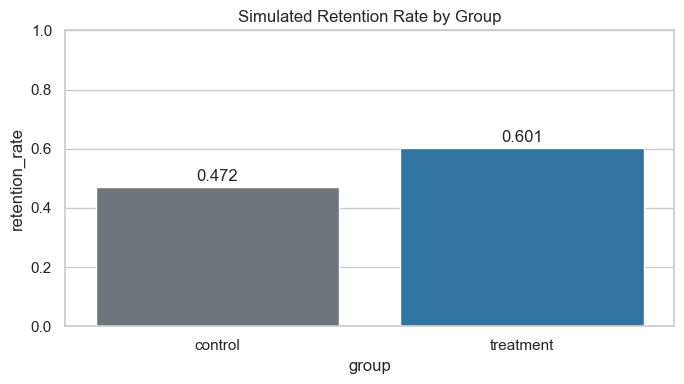

Saved summary: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/reports/week3_ab_test_summary.csv
Saved simulation details: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/reports/week3_high_risk_simulation.csv


In [5]:
# 5) Visualize and save outputs
rate_df = pd.DataFrame(
    {
        "group": ["control", "treatment"],
        "retention_rate": [p_c, p_t],
    }
)
 
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=rate_df,
    x="group",
    y="retention_rate",
    hue="group",
    dodge=False,
    legend=False,
    palette={"control": "#6c757d", "treatment": "#1f77b4"},
)
ax.set_ylim(0, 1)
ax.set_title("Simulated Retention Rate by Group")
for i, v in enumerate(rate_df["retention_rate"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()
 
reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
 
ab_results_path = reports_dir / "week3_ab_test_summary.csv"
high_risk_path = reports_dir / "week3_high_risk_simulation.csv"
 
ab_results.to_csv(ab_results_path, index=False)
high_risk.to_csv(high_risk_path, index=False)
 
print(f"Saved summary: {ab_results_path}")
print(f"Saved simulation details: {high_risk_path}")

## Step 6: Business Recommendation and Campaign Economics
Translate experiment metrics into a practical rollout recommendation and estimate net business value.

In [6]:
# 6) Recommendation from A/B results with cost/value metrics
significant = bool(p_value < ALPHA)

control_n = int(n_c)
treatment_n = int(n_t)
economics = estimate_campaign_economics(
    lift=lift,
    treatment_n=treatment_n,
    offer_cost=OFFER_COST,
    customer_value=CUSTOMER_VALUE,
)

incremental_retained = economics["incremental_retained"]
incremental_value = economics["incremental_value"]
total_offer_cost = economics["total_offer_cost"]
estimated_net_profit = economics["estimated_net_profit"]
roi = economics["roi"]

if significant and lift > 0:
    recommendation = (
        "Recommend rolling out the retention offer to high-risk customers. "
        f"Observed lift: {lift:.2%} (p={p_value:.4f}); "
        f"estimated incremental retained customers: {incremental_retained:.1f}; "
        f"estimated net profit in test-scale treatment group: ${estimated_net_profit:,.2f}."
    )
elif significant and lift < 0:
    recommendation = (
        "Do not roll out the current offer. "
        f"Observed negative lift: {lift:.2%} (p={p_value:.4f})."
    )
else:
    recommendation = (
        "Effect is not statistically significant. "
        "Run a larger or longer A/B test before rollout decisions."
    )

recommendation_df = pd.DataFrame(
    {
        "metric": [
            "significant",
            "lift",
            "p_value",
            "risk_threshold_used",
            "offers_sent",
            "incremental_retained_est",
            "customer_value",
            "offer_cost",
            "incremental_value_est",
            "total_offer_cost_est",
            "estimated_net_profit",
            "roi",
            "recommendation",
        ],
        "value": [
            significant,
            round(float(lift), 4),
            round(float(p_value), 6),
            round(float(RISK_THRESHOLD), 4),
            treatment_n,
            round(float(incremental_retained), 2),
            round(float(CUSTOMER_VALUE), 2),
            round(float(OFFER_COST), 2),
            round(float(incremental_value), 2),
            round(float(total_offer_cost), 2),
            round(float(estimated_net_profit), 2),
            round(float(roi), 4) if not np.isnan(roi) else np.nan,
            recommendation,
        ],
    }
)

display(recommendation_df)
print(recommendation)

recommendation_path = reports_dir / "week3_business_recommendation.csv"
recommendation_df.to_csv(recommendation_path, index=False)
print(f"Saved recommendation: {recommendation_path}")

,metric,value
0,significant,True
1,lift,0.1296
2,p_value,0.0
3,risk_threshold_used,0.39
4,offers_sent,1663
5,incremental_retained_est,215.58
6,customer_value,180.0
7,offer_cost,15.0
8,incremental_value_est,38805.18
9,total_offer_cost_est,24945.0


Recommend rolling out the retention offer to high-risk customers. Observed lift: 12.96% (p=0.0000); estimated incremental retained customers: 215.6; estimated net profit in test-scale treatment group: $13,860.18.
Saved recommendation: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/reports/week3_business_recommendation.csv
